# Monthly Modeling Pipeline
Load engineered NOAA climate features, evaluate regression/classification models, and record a light-weight forecasting workflow.

## Data loading

In [51]:
from pathlib import Path
import numpy as np
import pandas as pd

DATA_PATH = Path("../data/monthly_data.csv")

monthly = (
    pd.read_csv(DATA_PATH, parse_dates=['ym'])
    .sort_values(['STATION', 'year', 'month'])
    .reset_index(drop=True)
)

TRAIN_THRESHOLD = 2021
REL_EXTREME_Q = 0.90

print(f"Monthly rows: {len(monthly):,}, stations: {monthly['STATION'].nunique()}")
monthly.head()


Monthly rows: 2,400, stations: 7


,STATION,year,month,PRCP_sum,TMAX_mean,TMIN_mean,TMEAN,ym
0,USW00003017,1996,6,1.74,85.083333,53.291667,69.187500,1996-06-01
1,USW00003017,1996,7,1.01,87.967742,58.774194,73.370968,1996-07-01
2,USW00003017,1996,8,0.56,87.064516,56.129032,71.596774,1996-08-01
3,USW00003017,1996,9,2.34,74.600000,46.900000,60.750000,1996-09-01
4,USW00003017,1996,10,0.39,64.903226,36.774194,50.838710,1996-10-01


## Feature engineering

In [52]:
HEAT_THRESHOLD_C = 32.0  # ~90F
COLD_THRESHOLD_C = 0.0   # freezing point


def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.sort_values(['STATION', 'year', 'month']).copy()
    df['month'] = df['month'].astype(int)

    # Daily spread and rolling precipitation signals
    df['temp_range'] = df['TMAX_mean'] - df['TMIN_mean']
    df['prcp_roll3_mean'] = (
        df.groupby('STATION')['PRCP_sum']
        .transform(lambda s: s.rolling(window=3, min_periods=1).mean())
    )
    df['prcp_roll6_mean'] = (
        df.groupby('STATION')['PRCP_sum']
        .transform(lambda s: s.rolling(window=6, min_periods=1).mean())
    )

    # Rolling behavior for temperature
    df['tmean_roll3_mean'] = (
        df.groupby('STATION')['TMEAN']
        .transform(lambda s: s.rolling(window=3, min_periods=2).mean())
    )
    df['tmean_roll6_std'] = (
        df.groupby('STATION')['TMEAN']
        .transform(lambda s: s.rolling(window=6, min_periods=2).std())
    )

    # Cyclical encoding for the month feature
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12.0)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12.0)

    # Temperature/precipitation lags
    for lag in (1, 3, 6, 12):
        df[f'TMEAN_lag{lag}'] = df.groupby('STATION')['TMEAN'].shift(lag)
    for lag in (1, 3, 12):
        df[f'PRCP_lag{lag}'] = df.groupby('STATION')['PRCP_sum'].shift(lag)

    df['TMEAN_roll3'] = (
        df.groupby('STATION')['TMEAN']
        .transform(lambda s: s.rolling(window=3, min_periods=2).mean())
    )
    df['TMEAN_roll6'] = (
        df.groupby('STATION')['TMEAN']
        .transform(lambda s: s.rolling(window=6, min_periods=3).mean())
    )

    df['heat_extreme'] = (df['TMAX_mean'] >= HEAT_THRESHOLD_C).astype(int)
    df['cold_extreme'] = (df['TMIN_mean'] <= COLD_THRESHOLD_C).astype(int)

    monthly_station_mean = (
        df.groupby(['STATION', 'month'])['PRCP_sum'].transform('mean')
    )
    df['PRCP_anom'] = df['PRCP_sum'] - monthly_station_mean
    df['PRCP_to_month_mean'] = df['PRCP_sum'] / (monthly_station_mean + 1e-3)

    df['TMEAN_station_norm'] = (
        df['TMEAN'] - df.groupby('STATION')['TMEAN'].transform('mean')
    )
    df['PRCP_station_norm'] = (
        df['PRCP_sum'] - df.groupby('STATION')['PRCP_sum'].transform('mean')
    )
    df['PRCP_log'] = np.log1p(df['PRCP_sum'].clip(lower=0))

    return df


In [53]:
monthly_fe = add_engineered_features(monthly)


def fill_station_missing(df: pd.DataFrame) -> pd.DataFrame:
    """Forward fill within each station to avoid leaking future information."""
    return (
        df.groupby('STATION', group_keys=False)
        .apply(lambda grp: grp.ffill())
    )

monthly_fe = fill_station_missing(monthly_fe)
monthly_fe = monthly_fe.dropna(subset=['TMEAN', 'PRCP_sum']).reset_index(drop=True)

# Relative extreme heat label (train years only, station/month 90th percentile)
train_mask_rel = monthly_fe['year'] < TRAIN_THRESHOLD
station_month_quantiles = (
    monthly_fe[train_mask_rel]
    .groupby(['STATION', 'month'])['TMEAN']
    .quantile(REL_EXTREME_Q)
)
monthly_fe = monthly_fe.merge(
    station_month_quantiles.rename('tmean_quantile'),
    on=['STATION', 'month'],
    how='left'
)
monthly_fe['heat_extreme_rel'] = (
    monthly_fe['TMEAN'] >= monthly_fe['tmean_quantile']
).astype(int)
monthly_fe['heat_extreme_next_rel'] = (
    monthly_fe.groupby('STATION')['heat_extreme_rel'].shift(-1)
)
monthly_fe = monthly_fe.drop(columns=['tmean_quantile'])

monthly_fe['TMEAN_next'] = monthly_fe.groupby('STATION')['TMEAN'].shift(-1)
monthly_fe['TMAX_next'] = monthly_fe.groupby('STATION')['TMAX_mean'].shift(-1)
monthly_fe['TMIN_next'] = monthly_fe.groupby('STATION')['TMIN_mean'].shift(-1)
monthly_fe['PRCP_next'] = monthly_fe.groupby('STATION')['PRCP_sum'].shift(-1)

print(f'Feature engineered rows: {len(monthly_fe):,}')
monthly_fe.head()


Feature engineered rows: 2,400


/var/folders/x8/59lsc6h95bz9br5gwthbx0rw0000gn/T/ipykernel_25324/221946923.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda grp: grp.ffill())


,STATION,year,month,PRCP_sum,TMAX_mean,TMIN_mean,TMEAN,ym,temp_range,prcp_roll3_mean,...,PRCP_to_month_mean,TMEAN_station_norm,PRCP_station_norm,PRCP_log,heat_extreme_rel,heat_extreme_next_rel,TMEAN_next,TMAX_next,TMIN_next,PRCP_next
0,USW00003017,1996,6,1.74,85.083333,53.291667,69.187500,1996-06-01,31.791667,1.740000,...,0.995875,18.015303,0.606257,1.007958,0,0.0,73.370968,87.967742,58.774194,1.01
1,USW00003017,1996,7,1.01,87.967742,58.774194,73.370968,1996-07-01,29.193548,1.375000,...,0.524356,22.198771,-0.123743,0.698135,0,0.0,71.596774,87.064516,56.129032,0.56
2,USW00003017,1996,8,0.56,87.064516,56.129032,71.596774,1996-08-01,30.935484,1.103333,...,0.400306,20.424578,-0.573743,0.444686,0,0.0,60.750000,74.600000,46.900000,2.34
3,USW00003017,1996,9,2.34,74.600000,46.900000,60.750000,1996-09-01,27.700000,1.303333,...,2.595128,9.577803,1.206257,1.205971,0,0.0,50.838710,64.903226,36.774194,0.39
4,USW00003017,1996,10,0.39,64.903226,36.774194,50.838710,1996-10-01,28.129032,1.096667,...,0.432852,-0.333487,-0.743743,0.329304,0,0.0,37.183333,50.966667,23.400000,0.38


## Modeling dataframe

In [54]:
feature_cols = [
    'PRCP_sum', 'TMAX_mean', 'TMIN_mean', 'TMEAN',
    'temp_range', 'prcp_roll3_mean', 'prcp_roll6_mean', 'tmean_roll3_mean', 'tmean_roll6_std',
    'month_sin', 'month_cos',
    'TMEAN_lag1', 'TMEAN_lag3', 'TMEAN_lag6', 'TMEAN_lag12',
    'PRCP_lag1', 'PRCP_lag3', 'PRCP_lag12',
    'TMEAN_roll3', 'TMEAN_roll6',
    'heat_extreme', 'cold_extreme', 'PRCP_anom', 'PRCP_to_month_mean',
    'TMEAN_station_norm', 'PRCP_station_norm', 'PRCP_log'
]

reg_targets = ['TMEAN_next', 'TMAX_next', 'TMIN_next', 'PRCP_next']
clf_target = 'heat_extreme_next_rel'

model_df = monthly_fe.dropna(subset=feature_cols + reg_targets + [clf_target]).reset_index(drop=True)
summer_mask = model_df['month'].between(5, 9)

print('Modeling dataframe shape:', model_df.shape)
print('Relative extreme heat class balance (all months):')
print(model_df[clf_target].value_counts().rename('samples'))
print('Relative extreme heat class balance (May-Sep only):')
print(model_df.loc[summer_mask, clf_target].value_counts().rename('samples'))


Modeling dataframe shape: (2309, 37)
Relative extreme heat class balance (all months):
heat_extreme_next_rel
0.0    1980
1.0     329
Name: samples, dtype: int64
Relative extreme heat class balance (May-Sep only):
heat_extreme_next_rel
0.0    822
1.0    151
Name: samples, dtype: int64


## Train/test split and scaling

In [55]:
from sklearn.preprocessing import StandardScaler

def _log1p_prcp(series: pd.Series) -> pd.Series:
    return np.log1p(series.clip(lower=0))

def _inv_log1p_prcp(values: pd.Series) -> pd.Series:
    return np.expm1(values)

train_threshold = TRAIN_THRESHOLD  # train < 2021, test >= 2021
train_mask = model_df['year'] < train_threshold
test_mask = ~train_mask

X = model_df[feature_cols]
y_reg = model_df[reg_targets]

X_train, X_test = X[train_mask], X[test_mask]
y_reg_train, y_reg_test = y_reg[train_mask], y_reg[test_mask]

y_reg_train_transformed = y_reg_train.copy()
y_reg_train_transformed['PRCP_next'] = _log1p_prcp(y_reg_train_transformed['PRCP_next'])

y_reg_test_transformed = y_reg_test.copy()
y_reg_test_transformed['PRCP_next'] = _log1p_prcp(y_reg_test_transformed['PRCP_next'])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Classification subset: May-Sep only
clf_df = model_df[model_df['month'].between(5, 9)].copy()
clf_train_mask = clf_df['year'] < train_threshold
clf_test_mask = ~clf_train_mask

X_clf = clf_df[feature_cols]
y_clf = clf_df[clf_target].astype(int)

clf_scaler = StandardScaler()
X_clf_train_scaled = clf_scaler.fit_transform(X_clf[clf_train_mask])
X_clf_test_scaled = clf_scaler.transform(X_clf[clf_test_mask])
y_clf_train = y_clf[clf_train_mask]
y_clf_test = y_clf[clf_test_mask]

print('Regression samples - train/test:', X_train.shape[0], X_test.shape[0])
print('Classification samples (May-Sep) - train/test:', X_clf_train_scaled.shape[0], X_clf_test_scaled.shape[0])
print('Classification class counts (train):', y_clf_train.value_counts().to_dict())
print('Classification class counts (test):', y_clf_test.value_counts().to_dict())


Regression samples - train/test: 1980 329
Classification samples (May-Sep) - train/test: 833 140
Classification class counts (train): {0: 728, 1: 105}
Classification class counts (test): {0: 94, 1: 46}


## Regression models

In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

PRCP_TARGET = 'PRCP_next'

def _convert_predictions(pred_array):
    pred_df = pd.DataFrame(pred_array, columns=reg_targets)
    pred_df[PRCP_TARGET] = _inv_log1p_prcp(pred_df[PRCP_TARGET]).clip(lower=0)
    return pred_df


def summarize_regression(model, name):
    model.fit(X_train_scaled, y_reg_train_transformed)
    preds_df = _convert_predictions(model.predict(X_test_scaled))
    for col in reg_targets:
        rmse = mean_squared_error(y_reg_test[col], preds_df[col]) ** 0.5
        mae = mean_absolute_error(y_reg_test[col], preds_df[col])
        r2 = r2_score(y_reg_test[col], preds_df[col])
        print(f"{name} - {col}: RMSE={rmse:.3f}, MAE={mae:.3f}, R2={r2:.3f}")
    print()
    return preds_df.values, model

reg_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=1),
    'Gradient Boosting Regressor': MultiOutputRegressor(GradientBoostingRegressor(random_state=42))
}

reg_predictions = {}
fitted_models = {}
for model_name, estimator in reg_models.items():
    preds, fitted = summarize_regression(estimator, model_name)
    reg_predictions[model_name] = preds
    fitted_models[model_name] = fitted

y_reg_pred_lr = reg_predictions['Linear Regression']
y_reg_pred_rf = reg_predictions['Random Forest Regressor']
y_reg_pred_gb = reg_predictions['Gradient Boosting Regressor']
linreg = fitted_models['Linear Regression']
rf_reg = fitted_models['Random Forest Regressor']
gb_reg = fitted_models['Gradient Boosting Regressor']

rmse_naive = mean_squared_error(y_reg_test['TMEAN_next'], X_test['TMEAN_lag1']) ** 0.5
print(f"Naive baseline RMSE (TMEAN_next via lag1): {rmse_naive:.3f}")


Linear Regression - TMEAN_next: RMSE=3.371, MAE=2.550, R2=0.960
Linear Regression - TMAX_next: RMSE=3.834, MAE=2.916, R2=0.951
Linear Regression - TMIN_next: RMSE=3.354, MAE=2.501, R2=0.960
Linear Regression - PRCP_next: RMSE=2.206, MAE=1.372, R2=0.455

Random Forest Regressor - TMEAN_next: RMSE=3.059, MAE=2.348, R2=0.967
Random Forest Regressor - TMAX_next: RMSE=3.473, MAE=2.710, R2=0.960
Random Forest Regressor - TMIN_next: RMSE=2.995, MAE=2.236, R2=0.968
Random Forest Regressor - PRCP_next: RMSE=2.052, MAE=1.338, R2=0.528

Gradient Boosting Regressor - TMEAN_next: RMSE=3.166, MAE=2.369, R2=0.965
Gradient Boosting Regressor - TMAX_next: RMSE=3.588, MAE=2.725, R2=0.957
Gradient Boosting Regressor - TMIN_next: RMSE=3.195, MAE=2.414, R2=0.964
Gradient Boosting Regressor - PRCP_next: RMSE=2.069, MAE=1.357, R2=0.520

Naive baseline RMSE (TMEAN_next via lag1): 13.429


### One-month-ahead forecast
Use a persistence assumption: the most recent engineered features per station (through month *t*) are kept as the inputs for forecasting month *t+1*, while purely calendar-dependent features (month number, sine/cosine) and the obvious lag-1 values are updated. This keeps the pipeline transparent while acknowledging that we do not have fresh information for rolling features until the next observation arrives.

In [57]:
# Use the most recent record per station to forecast the next month
last_rows = monthly_fe.groupby('STATION').tail(1).reset_index(drop=True)
future_df = last_rows.copy()
future_df['month'] = future_df['month'] + 1
rollover = future_df['month'] == 13
future_df.loc[rollover, 'month'] = 1
future_df.loc[rollover, 'year'] += 1
future_df['month_sin'] = np.sin(2 * np.pi * future_df['month'] / 12.0)
future_df['month_cos'] = np.cos(2 * np.pi * future_df['month'] / 12.0)

future_df['TMEAN_lag1'] = last_rows['TMEAN']
future_df['PRCP_lag1'] = last_rows['PRCP_sum']

for col in ['TMEAN_lag3', 'TMEAN_lag6', 'TMEAN_lag12', 'PRCP_lag3', 'PRCP_lag12']:
    if col in future_df.columns:
        future_df[col] = last_rows[col]

persistence_cols = [
    'temp_range', 'prcp_roll3_mean', 'prcp_roll6_mean',
    'tmean_roll3_mean', 'tmean_roll6_std', 'TMEAN_roll3', 'TMEAN_roll6',
    'heat_extreme', 'cold_extreme', 'PRCP_anom', 'PRCP_to_month_mean',
    'TMEAN_station_norm', 'PRCP_station_norm'
]
for col in persistence_cols:
    if col in future_df.columns:
        future_df[col] = last_rows[col]

future_df['PRCP_log'] = np.log1p(future_df['PRCP_sum'].clip(lower=0))

X_future = future_df[feature_cols]
X_future_scaled = scaler.transform(X_future)


def _print_forecast(model, name):
    preds_df = _convert_predictions(model.predict(X_future_scaled))
    print(f'{name} forecast:')
    for col in reg_targets:
        print(f'  {col}: {preds_df.iloc[0][col]:.3f}')
    return preds_df

future_pred_lr = _print_forecast(linreg, 'Linear Regression')
future_pred_rf = _print_forecast(rf_reg, 'Random Forest')
future_pred_gb = _print_forecast(gb_reg, 'Gradient Boosting')


Linear Regression forecast:
  TMEAN_next: 32.830
  TMAX_next: 45.779
  TMIN_next: 19.880
  PRCP_next: 0.508
Random Forest forecast:
  TMEAN_next: 32.009
  TMAX_next: 44.903
  TMIN_next: 19.115
  PRCP_next: 0.383
Gradient Boosting forecast:
  TMEAN_next: 30.873
  TMAX_next: 44.739
  TMIN_next: 18.567
  PRCP_next: 0.496


In [58]:
from sklearn.model_selection import TimeSeriesSplit

# Rolling-origin evaluation for TMEAN_next
tscv = TimeSeriesSplit(n_splits=5)
cv_rmse = []
for split_idx, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    scaler_cv = StandardScaler()
    X_train_cv = scaler_cv.fit_transform(X.iloc[train_idx])
    X_test_cv = scaler_cv.transform(X.iloc[test_idx])
    y_train_cv = y_reg.iloc[train_idx]['TMEAN_next']
    y_test_cv = y_reg.iloc[test_idx]['TMEAN_next']

    gb_cv = GradientBoostingRegressor(random_state=42)
    gb_cv.fit(X_train_cv, y_train_cv)
    preds_cv = gb_cv.predict(X_test_cv)
    rmse_cv = mean_squared_error(y_test_cv, preds_cv) ** 0.5
    cv_rmse.append(rmse_cv)
    print(f'Split {split_idx}: RMSE={rmse_cv:.3f}')

print(f'Rolling CV RMSE avg: {np.mean(cv_rmse):.3f} ± {np.std(cv_rmse):.3f}')


Split 1: RMSE=5.552
Split 2: RMSE=4.066
Split 3: RMSE=3.666
Split 4: RMSE=3.652
Split 5: RMSE=5.033
Rolling CV RMSE avg: 4.394 ± 0.766


In [59]:
from sklearn.inspection import permutation_importance

# Permutation importance for Gradient Boosting on TMEAN_next
gb_single = GradientBoostingRegressor(random_state=42)
gb_single.fit(X_train_scaled, y_reg_train['TMEAN_next'])
perm = permutation_importance(
    gb_single,
    X_test_scaled,
    y_reg_test['TMEAN_next'],
    n_repeats=20,
    random_state=42,
    scoring='neg_mean_squared_error'
)

perm_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': perm.importances_mean,
    'std': perm.importances_std
}).sort_values('importance', ascending=False)

perm_df.head(10)


,feature,importance,std
3,TMEAN,114.108577,6.948988
10,month_cos,31.484609,2.072786
14,TMEAN_lag12,29.716491,1.559981
9,month_sin,23.773178,1.792343
1,TMAX_mean,14.266913,1.306921
2,TMIN_mean,8.922821,0.783027
13,TMEAN_lag6,2.809212,0.439964
8,tmean_roll6_std,2.472995,0.321886
12,TMEAN_lag3,1.983124,0.305188
24,TMEAN_station_norm,0.823795,0.221594


## Classification model (May-Sep relative extreme heat)
Focus on summer months (May–Sep) where the relative label is most meaningful. Logistic Regression with `class_weight="balanced"` is the sole classifier.

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

log_clf = LogisticRegression(max_iter=1000, solver='liblinear', class_weight='balanced')
log_clf.fit(X_clf_train_scaled, y_clf_train)
y_clf_prob = log_clf.predict_proba(X_clf_test_scaled)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_clf_test, y_clf_prob)
f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
best_idx = f1_scores[:-1].argmax()
best_threshold = thresholds[best_idx]
print(f'Logistic Regression optimal probability threshold (by F1): {best_threshold:.2f}')

for label, threshold in {
    'Default 0.5 threshold': 0.5,
    'F1-optimized threshold': best_threshold,
}.items():
    preds = (y_clf_prob >= threshold).astype(int)
    print(f"Logistic Regression ({label})")
    print(classification_report(y_clf_test, preds, digits=3, zero_division=0))
    print('Confusion matrix:')
    print(confusion_matrix(y_clf_test, preds))

print(f"Logistic Regression ROC AUC: {roc_auc_score(y_clf_test, y_clf_prob):.3f}")


Logistic Regression optimal probability threshold (by F1): 0.52
Logistic Regression (Default 0.5 threshold)
              precision    recall  f1-score   support

           0      0.855     0.564     0.679        94
           1      0.474     0.804     0.597        46

    accuracy                          0.643       140
   macro avg      0.665     0.684     0.638       140
weighted avg      0.730     0.643     0.652       140

Confusion matrix:
[[53 41]
 [ 9 37]]
Logistic Regression (F1-optimized threshold)
              precision    recall  f1-score   support

           0      0.857     0.638     0.732        94
           1      0.514     0.783     0.621        46

    accuracy                          0.686       140
   macro avg      0.686     0.710     0.676       140
weighted avg      0.744     0.686     0.695       140

Confusion matrix:
[[60 34]
 [10 36]]
Logistic Regression ROC AUC: 0.725


Per-station TMEAN_next metrics (using Random Forest predictions):
       STATION  rmse_tmean  r2_tmean  samples
1  USW00012839    1.932871  0.854660       47
4  USW00093134    2.236806  0.882146       47
3  USW00024233    2.487606  0.938857       47
5  USW00094789    3.270486  0.950329       47
2  USW00023183    3.422408  0.948566       47
0  USW00003017    3.725158  0.950455       47
6  USW00094846    3.780647  0.951683       47


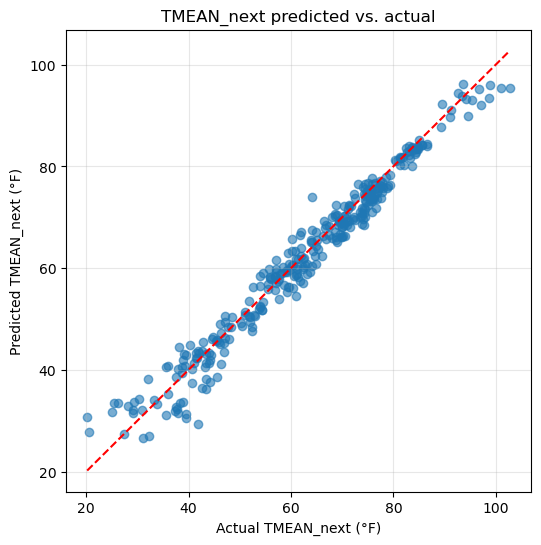

In [66]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score

best_reg_name = 'Random Forest Regressor'
reg_pred_df = pd.DataFrame(reg_predictions[best_reg_name], columns=reg_targets)

test_targets_df = y_reg_test.reset_index(drop=True)
test_meta = model_df.loc[test_mask, ['STATION']].reset_index(drop=True)

station_metrics = []
for station, grp in test_meta.groupby('STATION'):
    idx = grp.index
    y_true = test_targets_df.loc[idx, 'TMEAN_next']
    y_pred = reg_pred_df.loc[idx, 'TMEAN_next']
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    station_metrics.append({'STATION': station, 'rmse_tmean': rmse, 'r2_tmean': r2, 'samples': len(idx)})

station_metrics_df = pd.DataFrame(station_metrics).sort_values('rmse_tmean')
print('Per-station TMEAN_next metrics (using Random Forest predictions):')
print(station_metrics_df)

plt.figure(figsize=(6, 6))
plt.scatter(test_targets_df['TMEAN_next'], reg_pred_df['TMEAN_next'], alpha=0.6)
lims = [min(test_targets_df['TMEAN_next'].min(), reg_pred_df['TMEAN_next'].min()),
        max(test_targets_df['TMEAN_next'].max(), reg_pred_df['TMEAN_next'].max())]
plt.plot(lims, lims, color='red', linestyle='--')
plt.xlabel('Actual TMEAN_next (°F)')
plt.ylabel('Predicted TMEAN_next (°F)')
plt.title('TMEAN_next predicted vs. actual')
plt.grid(True, alpha=0.3)
plt.show()


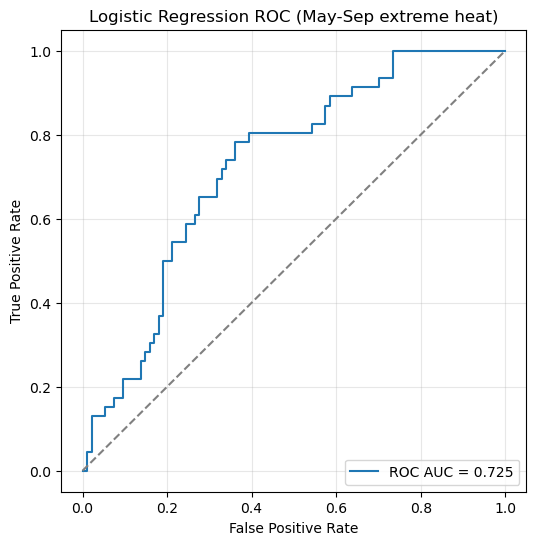

In [69]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_clf_test, y_clf_prob)
roc_auc = roc_auc_score(y_clf_test, y_clf_prob)
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC (May-Sep extreme heat)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

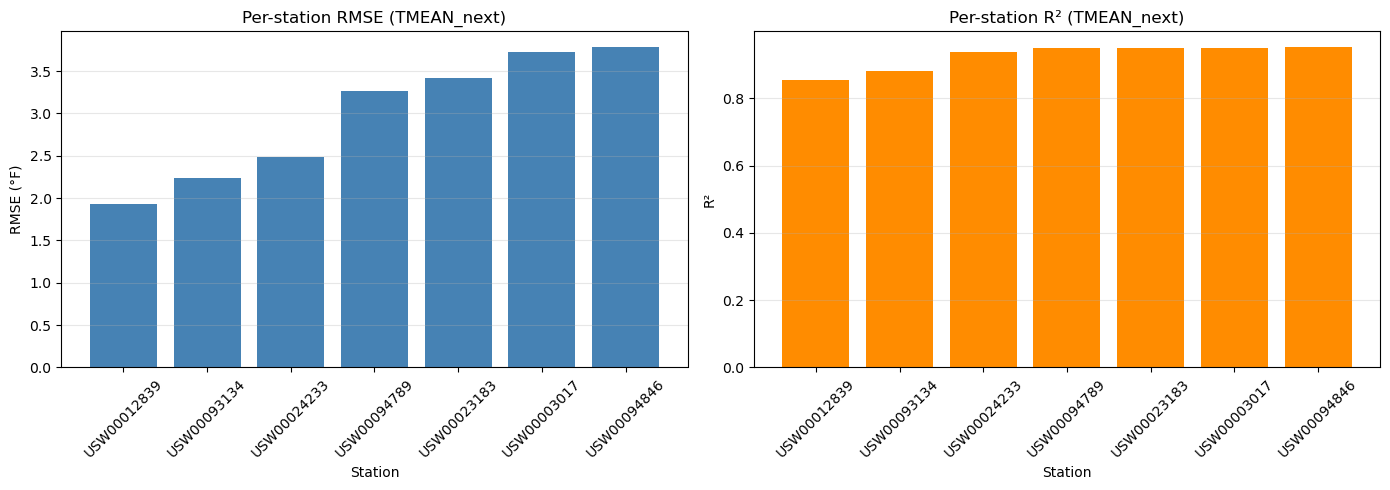

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

station_metrics_df.sort_values('rmse_tmean', inplace=True)

# RMSE
axes[0].bar(station_metrics_df['STATION'], station_metrics_df['rmse_tmean'], color='steelblue')
axes[0].set_title('Per-station RMSE (TMEAN_next)')
axes[0].set_xlabel('Station')
axes[0].set_ylabel('RMSE (°F)')
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)  

# R*2
axes[1].bar(station_metrics_df['STATION'], station_metrics_df['r2_tmean'], color='darkorange')
axes[1].set_title('Per-station R² (TMEAN_next)')
axes[1].set_xlabel('Station')
axes[1].set_ylabel('R²')
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45) 

plt.tight_layout()
plt.show()
